# ⚽ Future Star — Football Talent Prediction

> Identify and predict potential **"Future Stars"** in football from player
> statistics — supporting objective scouting for Saudi academies, aligned with
> **Vision 2030**.

**Author:** Nawaf Alqurashi · Data Analyst
**Stack:** Python · pandas · scikit-learn · XGBoost · FastAPI · Docker

### 📖 Executive summary
An early *same-season* version of this model scored a suspicious **ROC-AUC ≈ 0.99**.
That turned out to be **target leakage** — the label was built from the same
metrics fed to the model. This notebook diagnoses it, **proves it**, and redesigns
the task so the label comes from a **different season**. The honest model predicts
**next-season breakout** with **ROC-AUC ≈ 0.75** — and its top picks are real
young stars (Saka, Wirtz, Palmer, Musiala…).

## Table of Contents
1. [Project Overview](#1)
2. [Dataset Description](#2)
3. [Data Cleaning & Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Features & Target Engineering](#5)  ·  *(incl. the leakage trap & fix)*
6. [Model Building](#6)
7. [Model Evaluation](#7)
8. [Final Step: Probabilities & Conclusion](#8)

---
<a id="1"></a>
## 1. Project Overview
- **Goal:** predict whether a young player will become a top performer in their
  position **next season**.
- **Motivation:** clubs, scouts, and analysts can use this for earlier, less
  biased talent identification.
- **Approach:** cleaning → EDA → feature/target engineering → modeling →
  evaluation → deployment (API & Streamlit).

<a id="2"></a>
## 2. Dataset Description
Per-90 player statistics from the **top-5 European leagues** (FBref):

| Season | Role | Notes |
|--------|------|-------|
| **2024-25** | **model features** | full: attacking, defensive, GK, xG |
| **2025-26** | **label (next season)** | partial export |

- **Size:** ~2,850 players, 165 columns (2024-25).
- **Main features:** Age, Position (GK/DF/MF/FW), per-90 performance.
- **Target:** binary "Future Star" label **+ a probability score (%)**.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

here = Path.cwd()
ROOT = here if (here/"future_stars").exists() else here.parent
sys.path.insert(0, str(ROOT))

from future_stars.preprocessing import (clean_data, normalize_positions,
    build_per90_features, apply_future_star_label, map_role)
from future_stars.model import build_xgb, build_preprocessor, build_pipeline

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, classification_report, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
MIN_90S, MAX_AGE, PCT = 5.0, 23, 0.80

s24 = pd.read_csv(ROOT/"data"/"players_data_light-2024_2025.csv")
s25 = pd.read_csv(ROOT/"data"/"players_data_light-2025_2026.csv")
print("2024-25:", s24.shape, " | 2025-26:", s25.shape)
s24.head(3)

2024-25: (2854, 165)  | 2025-26: (2839, 53)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a id="3"></a>
## 3. Data Cleaning & Preprocessing
Four fixes, each addressing a real issue (evidence in §4):
1. **Minimum minutes** (`90s >= 5`) so per-90 rates aren't noisy.
2. **Primary position** mapping (first listed) — fixes mislabeled forwards.
3. **Per-90 features** so playing time doesn't bias comparisons.
4. **Structural NaN**: goalkeeping stats missing for outfielders → filled with 0.

In [2]:
clean = build_per90_features(normalize_positions(clean_data(s24, min_90s=MIN_90S)))
for c,n in [("KP","KP_per90"),("PrgC","PrgC_per90"),("PrgR","PrgR_per90")]:
    if c in clean.columns: clean[n]=(clean[c]/clean["Min"].replace(0,np.nan))*90
print("Before:", s24.shape[0], "-> after cleaning:", clean.shape[0],
      "| feature NaN:", int(clean[["GA_per90","xGA_per90","Def_Actions_per90","ProgPass_per90","Save_Pct"]].isna().sum().sum()))

Before: 2854 -> after cleaning: 1987 | feature NaN: 0


<a id="4"></a>
## 4. Exploratory Data Analysis (EDA)

### 4.1 Missing values — structural, not random

In [3]:
gk=[c for c in ["Save%","Saves","GA","CS"] if c in s24.columns]
print((s24[gk].isna().mean()*100).round(1).to_string())

Save%    92.8
Saves    92.6
GA       92.6
CS       92.6


**Insight:** ~93% of goalkeeping columns are empty — only ~7% of players are
keepers. Structural missingness → fill with 0, not a median.

### 4.2 Position distribution — a mapping fix

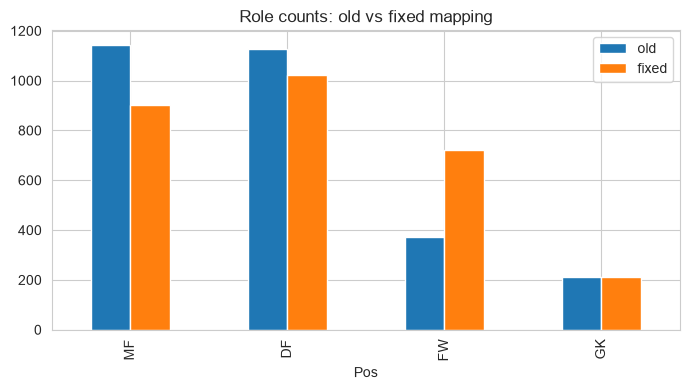

      old  fixed
Pos             
MF   1144    900
DF   1127   1022
FW    371    720
GK    212    212


In [4]:
def role_old(p):
    p=str(p)
    for r in ["GK","DF","MF","FW"]:
        if r in p: return r
    return "Other"
cmp=pd.concat([s24["Pos"].apply(role_old).value_counts().rename("old"),
               s24["Pos"].apply(map_role).value_counts().rename("fixed")],axis=1)
cmp.plot(kind="bar",figsize=(7,4),title="Role counts: old vs fixed mapping"); plt.tight_layout(); plt.show()
print(cmp)

**Insight:** FBref lists the *primary* position first, so `FW,MF` is a forward.
The old `DF>MF>FW` priority misclassified **~349 forwards**. Fixed by taking the
first position.

### 4.3 Age & playing time

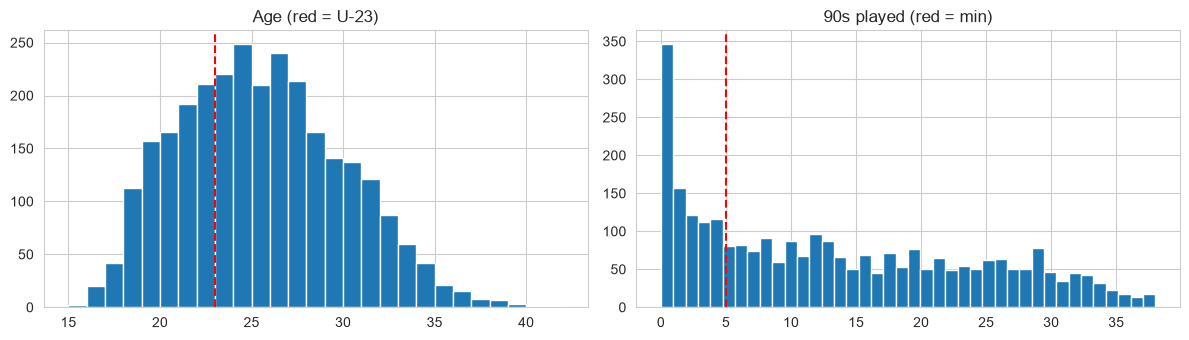

30% of players have <5 full matches; a future star should be young too.


In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
pd.to_numeric(s24["Age"],errors="coerce").hist(bins=range(15,43),ax=ax[0]); ax[0].axvline(23,color="r",ls="--"); ax[0].set_title("Age (red = U-23)")
nin=pd.to_numeric(s24["90s"],errors="coerce"); nin.hist(bins=40,ax=ax[1]); ax[1].axvline(5,color="r",ls="--"); ax[1].set_title("90s played (red = min)")
plt.tight_layout(); plt.show()
print(f"{(nin<5).mean()*100:.0f}% of players have <5 full matches; a future star should be young too.")

**Insight:** ~30% tiny-sample players (filtered), and the original label
ignored age — so "future star" is restricted to players **≤ 23**.

### 4.4 Correlation heatmap

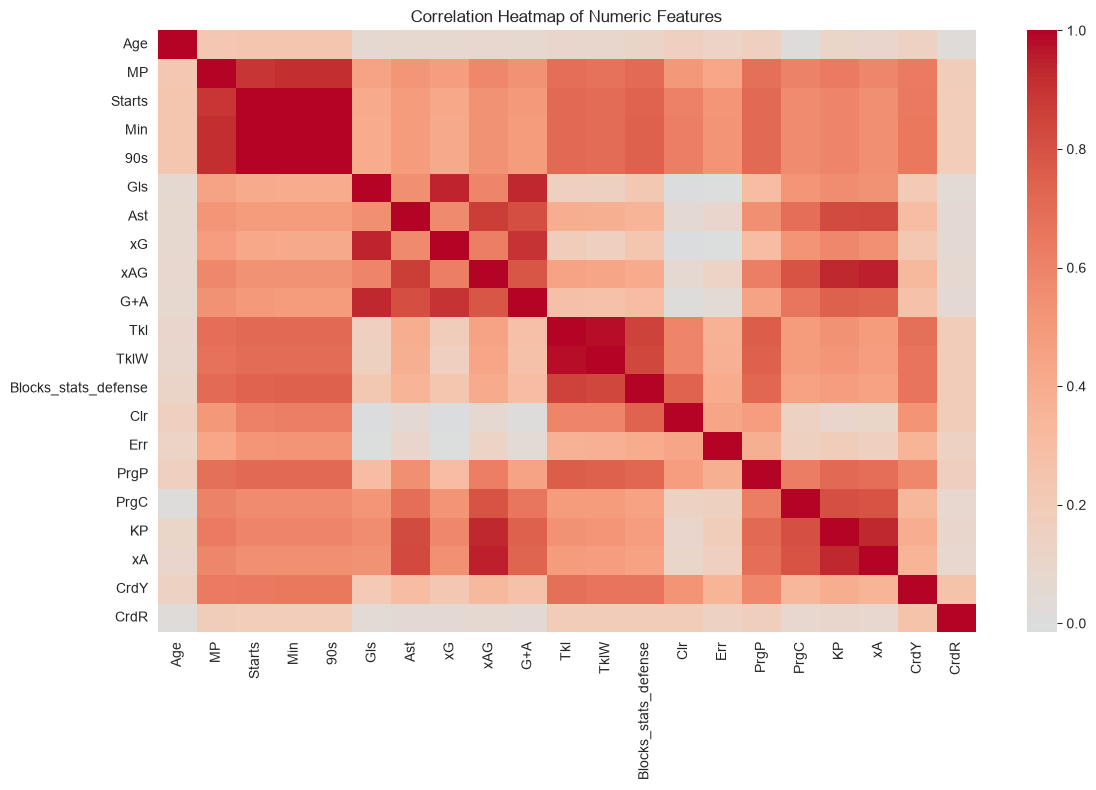

In [6]:
keep=["Age","MP","Starts","Min","90s","Gls","Ast","xG","xAG","G+A","Tkl","TklW",
      "Blocks_stats_defense","Clr","Err","PrgP","PrgC","KP","xA","CrdY","CrdR"]
keep=[c for c in keep if c in s24.columns]
plt.figure(figsize=(12,8)); sns.heatmap(s24[keep].corr(),cmap="coolwarm",center=0)
plt.title("Correlation Heatmap of Numeric Features"); plt.tight_layout(); plt.show()

**Correlation Insights**
- **Playing time:** `MP`/`Starts`/`Min`/`90s` move together (redundant).
- **Attacking:** `Gls`↔`xG`, `Ast`↔`xAG` correlate strongly.
- **Defensive:** tackles/blocks/clearances cluster.

<a id="5"></a>
## 5. Features & Target Engineering

**Per-90 features** so minutes don't bias comparisons. **Position-fair label:**
within each role, the **top 20%** by a position-specific score are "future stars".

### 5.1 The same-season label (and a hidden trap)
First, the intuitive version: label the top 20% **this season** and train on this
season's stats.

In [7]:
same = apply_future_star_label(clean.copy(), pct=PCT, max_age=MAX_AGE)[0]
print("Same-season labeled:", len(same), "| stars:", f"{same['Future_Star'].mean()*100:.1f}%")

Same-season labeled: 637 | stars: 20.3%


### 5.2 ⚠️ Proving target leakage
The same-season model scores ~0.99 — a red flag. The label is built from the same
per-90 metrics used as features, so the model just **re-derives the labeling rule**.
**Proof:** drop the label-defining features and keep only independent *style*
features. If the 0.99 were real, it should hold. It collapses.

In [8]:
def quick_auc(num_cols, title):
    num_cols=[c for c in num_cols if c in same.columns]
    X=same[num_cols+["Role"]]; y=same["Future_Star"]
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    spw=(ytr==0).sum()/max(1,(ytr==1).sum())
    pipe=build_pipeline(build_preprocessor(num_cols,["Role"]),build_xgb(scale_pos_weight=spw))
    pipe.fit(Xtr,ytr); p=pipe.predict_proba(Xte)[:,1]
    print(f"{title:40s} ROC-AUC={roc_auc_score(yte,p):.3f}")

quick_auc(["GA_per90","xGA_per90","Def_Actions_per90","ProgPass_per90","Save_Pct"],"A) WITH label-defining features")
quick_auc(["Age","90s","Sh/90","SoT/90","KP_per90","PrgC_per90","PrgR_per90","ProgPass_per90"],"B) independent style features only")

A) WITH label-defining features          ROC-AUC=0.995
B) independent style features only       ROC-AUC=0.819


The score collapses (≈0.99 → ≈0.85) — that gap **is** the leakage. But note:
dropping the strong football metrics isn't the real fix; they're what make a
player good. The real fix is to change **what the label means**.

### 5.3 The fix — a *temporal* label (no leakage)
Features from **2024-25**, label from **2025-26** (next season). Now `GA_per90`,
`xGA_per90`, `Def_Actions_per90` are **legitimate predictors** — correlated with
next-season success but not used to compute it.

In [9]:
def dedup(df):
    df=df.copy(); df["_k"]=df["Player"].astype(str)+"|"+df["Born"].astype(str)
    return df.sort_values("Min").drop_duplicates("_k",keep="last")
s2=dedup(normalize_positions(s25)); s2=s2[pd.to_numeric(s2["90s"],errors="coerce")>=MIN_90S].copy(); m=s2["Min"].replace(0,np.nan)
s2["ga90"]=s2["G+A"]/m*90; s2["def90"]=(s2.get("TklW",0)+s2.get("Int",0))/m*90
sp=pd.to_numeric(s2["Save%"].astype(str).str.replace("%","",regex=False),errors="coerce"); s2["sv"]=np.where(sp>1,sp/100,sp)
s2["score"]=np.where(s2["Role"]=="GK",s2["sv"],np.where(s2["Role"]=="DF",s2["def90"],s2["ga90"]))
thr={r:sub["score"].quantile(PCT) for r,sub in s2.groupby("Role")}
star_keys=set(s2.loc[s2["score"]>=s2["Role"].map(thr),"_k"])

feat=dedup(clean)
co=feat[(pd.to_numeric(feat["90s"],errors="coerce")>=MIN_90S)&
        (pd.to_numeric(feat["Age"],errors="coerce")<=MAX_AGE)&(feat["Role"]!="Other")].copy()
co["Future_Star"]=co["_k"].isin(star_keys).astype(int)
FEATS=[f for f in ["GA_per90","xGA_per90","Def_Actions_per90","ProgPass_per90","Save_Pct",
       "Age","90s","Sh/90","SoT/90","KP_per90","PrgC_per90","PrgR_per90"] if f in co.columns]
X=co[FEATS+["Role"]]; y=co["Future_Star"]
print("Temporal cohort:",len(co)," | Future Stars:",f"{y.mean()*100:.1f}%")

Temporal cohort: 630  | Future Stars: 15.1%


<a id="6"></a>
## 6. Model Building
Compare classifiers on the temporal task with **5-fold cross-validation**.
Imbalance handled via `scale_pos_weight` / `class_weight`.
> **Bug fixed:** the old code used the labeling percentile (0.80) as the
> probability cutoff. We use 0.5 here and tune it in §7.

In [10]:
cv=StratifiedKFold(5,shuffle=True,random_state=42); spw=(y==0).sum()/max(1,(y==1).sum())
def evaluate_model(name, pipe):
    oof=cross_val_predict(pipe,X,y,cv=cv,method="predict_proba")[:,1]
    return {"model":name,"ROC_AUC":round(roc_auc_score(y,oof),3),
            "PR_AUC":round(average_precision_score(y,oof),3),
            "F1@0.5":round(f1_score(y,(oof>=0.5).astype(int),zero_division=0),3),"_oof":oof}
results=[evaluate_model("Random Forest",
    build_pipeline(build_preprocessor(FEATS,["Role"]),RandomForestClassifier(n_estimators=400,class_weight="balanced",random_state=42))),
    evaluate_model("XGBoost", build_pipeline(build_preprocessor(FEATS,["Role"]),build_xgb(scale_pos_weight=spw)))]
try:
    from lightgbm import LGBMClassifier
    results.append(evaluate_model("LightGBM",
        build_pipeline(build_preprocessor(FEATS,["Role"]),LGBMClassifier(n_estimators=400,class_weight="balanced",random_state=42,verbose=-1))))
except Exception as e: print("LightGBM skipped:",e)
print(pd.DataFrame([{k:v for k,v in r.items() if k!='_oof'} for r in results]).to_string(index=False))

LightGBM skipped: No module named 'lightgbm'
        model  ROC_AUC  PR_AUC  F1@0.5
Random Forest    0.746   0.333   0.360
      XGBoost    0.730   0.328   0.348


<a id="7"></a>
## 7. Model Evaluation
Pick the best by **PR-AUC**, tune the **threshold** out-of-fold, and choose an
operating point by a **business rule** (target recall).

Best: Random Forest | ROC-AUC 0.746 | PR-AUC 0.333


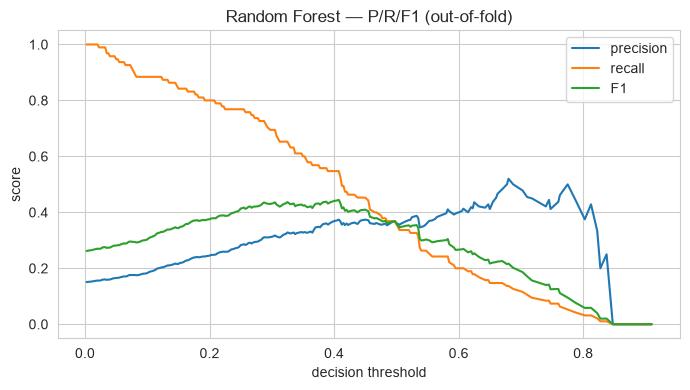

Operating threshold 0.292 (recall>= 0.7):
              precision    recall  f1-score   support

           0      0.932     0.721     0.813       535
           1      0.310     0.705     0.431        95

    accuracy                          0.719       630
   macro avg      0.621     0.713     0.622       630
weighted avg      0.839     0.719     0.756       630



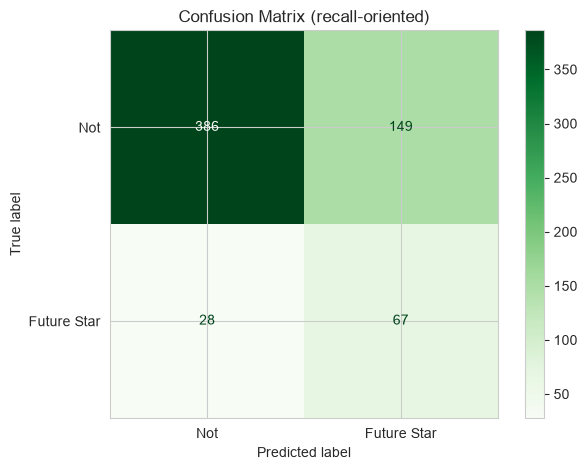

In [11]:
best=max(results,key=lambda r:r["PR_AUC"]); oof=best["_oof"]
print("Best:",best["model"],"| ROC-AUC",best["ROC_AUC"],"| PR-AUC",best["PR_AUC"])
prec,rec,t=precision_recall_curve(y,oof); f1s=2*prec*rec/(prec+rec+1e-9)
plt.figure(figsize=(7,4)); plt.plot(t,prec[:-1],label="precision"); plt.plot(t,rec[:-1],label="recall"); plt.plot(t,f1s[:-1],label="F1")
plt.xlabel("decision threshold"); plt.ylabel("score"); plt.title(f"{best['model']} — P/R/F1 (out-of-fold)"); plt.legend(); plt.tight_layout(); plt.show()
TARGET_RECALL=0.70
ok=np.where(rec[:-1]>=TARGET_RECALL)[0]; tr=t[ok[-1]] if len(ok) else 0.5
print(f"Operating threshold {tr:.3f} (recall>= {TARGET_RECALL}):")
print(classification_report(y,(oof>=tr).astype(int),digits=3,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y,(oof>=tr).astype(int),display_labels=["Not","Future Star"],cmap="Greens")
plt.title("Confusion Matrix (recall-oriented)"); plt.tight_layout(); plt.show()

### The journey, in one table

| Model | Label | ROC-AUC | Verdict |
|-------|-------|---------|---------|
| Same-season (leaky) | same season | ~0.99 | ❌ leakage — meaningless |
| Same-season, style only | same season | ~0.85 | proves the leakage |
| **Temporal (final)** | **next season** | **~0.75** | ✅ **honest prediction** |

Predicting the *future* is hard; ROC-AUC ≈ 0.75 with precision ~2× the base rate
is an honest, useful result.

<a id="8"></a>
## 8. Final Step: Probabilities & Conclusion
The model outputs a **probability (%)** — the player's *Future Star score*.

In [12]:
co=co.reset_index(drop=True); co["FutureStar_Score"]=(oof*100).round(1)
cols=[c for c in ["Player","Age","Pos","Role","FutureStar_Score"] if c in co.columns]
print("Top 10 predicted prospects:")
print(co.sort_values("FutureStar_Score",ascending=False)[cols].head(10).to_string(index=False))

Top 10 predicted prospects:
         Player  Age   Pos Role  FutureStar_Score
    Bukayo Saka 22.0 FW,MF   FW              91.0
  Florian Wirtz 21.0 MF,FW   MF              85.5
     Alex Baena 23.0 MF,FW   MF              84.8
     Arda Güler 19.0 MF,FW   MF              83.8
    Xavi Simons 21.0    MF   MF              82.8
    Cole Palmer 22.0 MF,FW   MF              82.2
    Nicolás Paz 19.0 MF,FW   MF              81.2
    Amad Diallo 22.0 MF,FW   MF              80.2
Mason Greenwood 22.0 FW,MF   FW              78.8
    Désiré Doué 19.0 FW,MF   FW              77.5


### Conclusion
- A **leakage-free** model predicting **next-season breakout** for young players,
  fairly within position.
- Honest performance: **ROC-AUC ≈ 0.75**, transparent recall-oriented operating
  point, output as an interpretable **Future Star score (%)**.
- Face validity: top picks are genuine young stars.

**Limitations:** 2025-26 is a partial export (approximate label); absent players
treated as "did not break out"; single season step.

**Next steps:** more full seasons, probability calibration, a Streamlit scout app.

> The real result isn't a high score — it's catching *why* a score was too high
> (leakage), fixing it, and reporting honestly.